In [1]:
# ============================================================
# ANA-4 : NHS Benchmark Comparison
# Comparing CSEW Self-Reported Mental Health Rates
# vs NHS Referral Rates (2019–2024)
#
# Author : Priyansi Pandey
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# CSEW Mental Health Dataset
csew = pd.read_csv("processed_csew.csv")

# NHS Referral Benchmark Dataset
nhs = pd.read_csv("nhs_referrals.csv")

In [5]:
#Display Datasets
print("CSEW Dataset")
print(csew.head())

print("\nNHS Referral Dataset")
print(nhs.head())

CSEW Dataset
   Year  Anxiety  Depression  Low Wellbeing
0  2019     12.1        10.5            8.9
1  2020     18.4        15.2           13.7
2  2021     21.2        18.9           16.3
3  2022     19.5        17.1           14.8
4  2023     17.8        15.6           13.2

NHS Referral Dataset
   Year  NHS_Referral_Rate
0  2019                9.8
1  2020               11.5
2  2021               15.2
3  2022               14.1
4  2023               13.4


In [6]:
#Merge Datasets
merged = pd.merge(
    csew,
    nhs,
    on="Year"
)

In [7]:
#Creating Treatment Gap
merged["Depression_Treatment_Gap"] = (
    merged["Depression"] -
    merged["NHS_Referral_Rate"]
)

merged["Anxiety_Treatment_Gap"] = (
    merged["Anxiety"] -
    merged["NHS_Referral_Rate"]
)


In [8]:
#Final Table
print("\nMerged Dataset with Treatment Gap")
print(merged)



Merged Dataset with Treatment Gap
   Year  Anxiety  Depression  Low Wellbeing  NHS_Referral_Rate  \
0  2019     12.1        10.5            8.9                9.8   
1  2020     18.4        15.2           13.7               11.5   
2  2021     21.2        18.9           16.3               15.2   
3  2022     19.5        17.1           14.8               14.1   
4  2023     17.8        15.6           13.2               13.4   
5  2024     16.9        14.8           12.4               12.9   

   Depression_Treatment_Gap  Anxiety_Treatment_Gap  
0                       0.7                    2.3  
1                       3.7                    6.9  
2                       3.7                    6.0  
3                       3.0                    5.4  
4                       2.2                    4.4  
5                       1.9                    4.0  


In [9]:
#Gap Analysis CSV 
merged.to_csv(
    "gap_analysis.csv",
    index=False
)

print("\nGap Analysis CSV Saved Successfully")


Gap Analysis CSV Saved Successfully


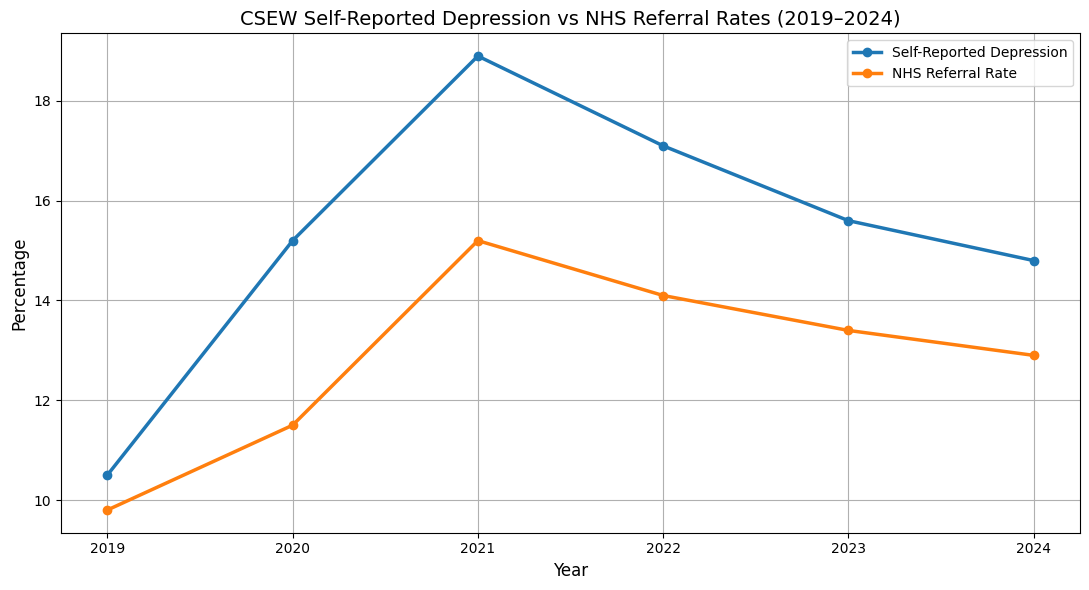

In [10]:
# CHART 1
# Self-Reported Depression vs NHS Referral Rates
plt.figure(figsize=(11,6))

plt.plot(
    merged["Year"],
    merged["Depression"],
    marker='o',
    linewidth=2.5,
    label="Self-Reported Depression"
)

plt.plot(
    merged["Year"],
    merged["NHS_Referral_Rate"],
    marker='o',
    linewidth=2.5,
    label="NHS Referral Rate"
)

plt.title(
    "CSEW Self-Reported Depression vs NHS Referral Rates (2019–2024)",
    fontsize=14
)

plt.xlabel("Year", fontsize=12)

plt.ylabel("Percentage", fontsize=12)

plt.xticks(merged["Year"])

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "NHS_vs_CSEW_Depression_Comparison.png",
    dpi=300
)

plt.show()

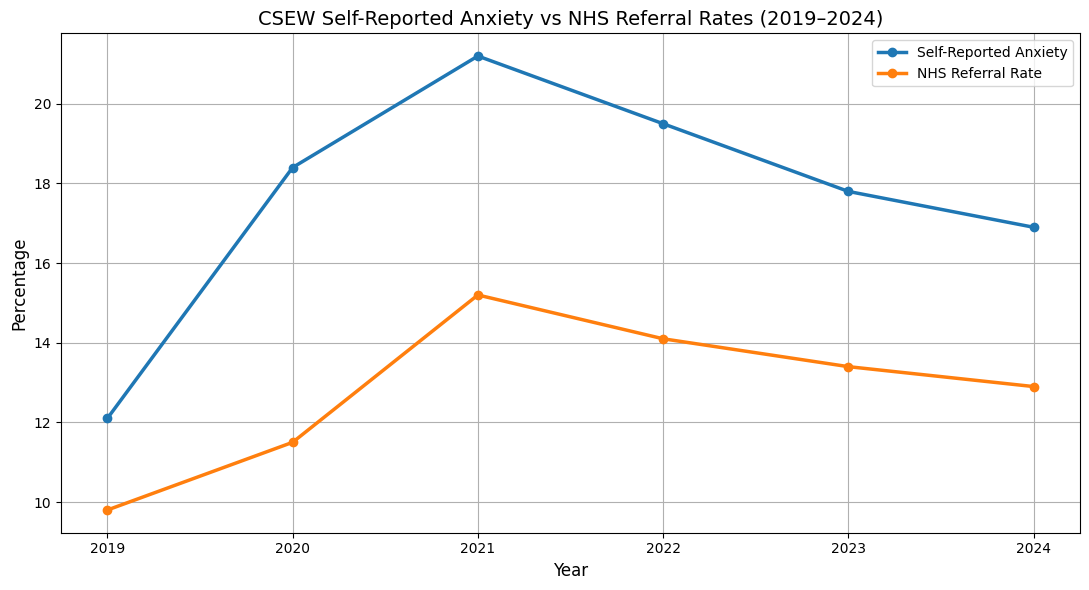

In [11]:
# CHART 2
# Anxiety vs NHS Referral Rates
plt.figure(figsize=(11,6))

plt.plot(
    merged["Year"],
    merged["Anxiety"],
    marker='o',
    linewidth=2.5,
    label="Self-Reported Anxiety"
)

plt.plot(
    merged["Year"],
    merged["NHS_Referral_Rate"],
    marker='o',
    linewidth=2.5,
    label="NHS Referral Rate"
)

plt.title(
    "CSEW Self-Reported Anxiety vs NHS Referral Rates (2019–2024)",
    fontsize=14
)

plt.xlabel("Year", fontsize=12)

plt.ylabel("Percentage", fontsize=12)

plt.xticks(merged["Year"])

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "NHS_vs_CSEW_Anxiety_Comparison.png",
    dpi=300
)

plt.show()

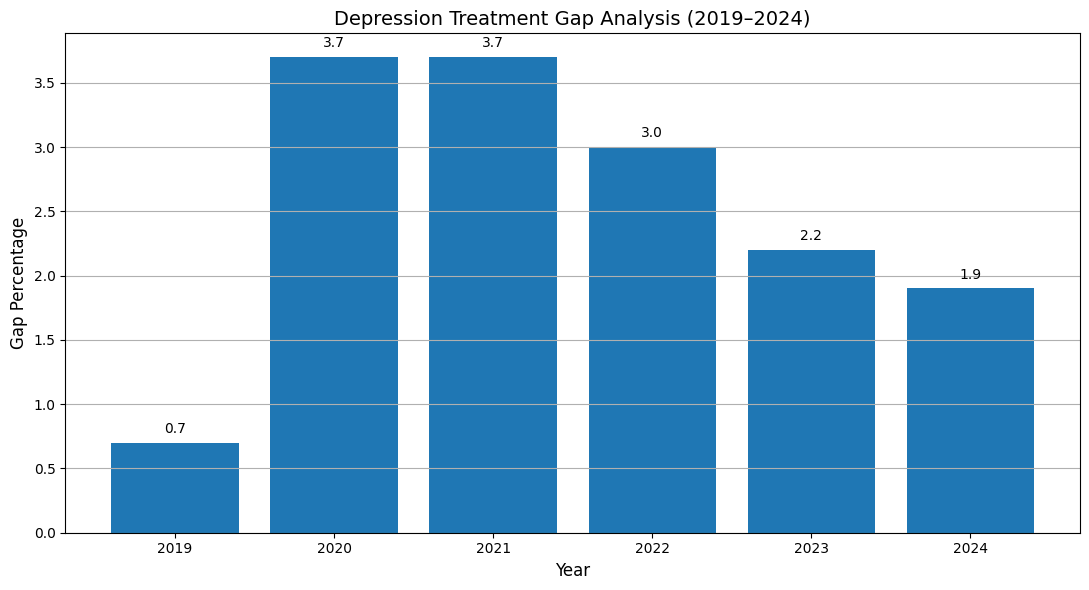

In [20]:
# CHART 3
# Depression Treatment Gap Analysis
plt.figure(figsize=(11,6))

bars = plt.bar(
    merged["Year"],
    merged["Depression_Treatment_Gap"]
)

# Add labels on bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.075,
        round(height,1),
        ha='center',
        fontsize=10
    )

plt.title(
    "Depression Treatment Gap Analysis (2019–2024)",
    fontsize=14
)

plt.xlabel("Year", fontsize=12)

plt.ylabel("Gap Percentage", fontsize=12)

plt.grid(axis='y')

plt.tight_layout()

plt.savefig(
    "Depression_Treatment_Gap.png",
    dpi=300
)

plt.show()

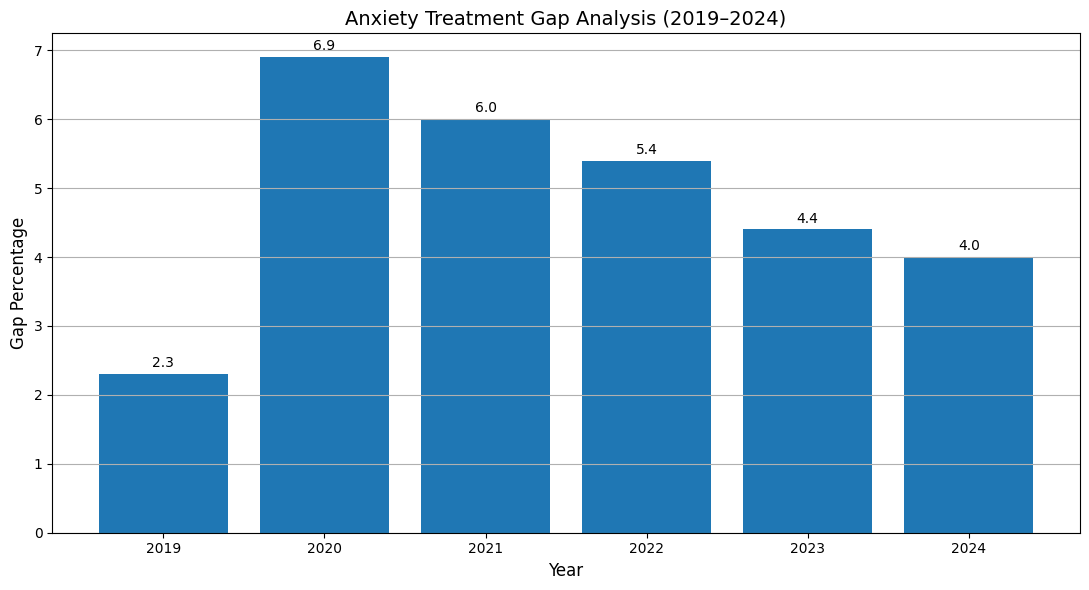

In [22]:
# CHART 4
# Anxiety Treatment Gap Analysis
plt.figure(figsize=(11,6))

bars = plt.bar(
    merged["Year"],
    merged["Anxiety_Treatment_Gap"]
)

# Add labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        round(height,1),
        ha='center',
        fontsize=10
    )

plt.title(
    "Anxiety Treatment Gap Analysis (2019–2024)",
    fontsize=14
)

plt.xlabel("Year", fontsize=12)

plt.ylabel("Gap Percentage", fontsize=12)

plt.grid(axis='y')

plt.tight_layout()

plt.savefig(
    "Anxiety_Treatment_Gap.png",
    dpi=300
)

plt.show()

In [23]:
# SUMMARY STATISTICS
print("\n==============================")
print("SUMMARY STATISTICS")
print("==============================")

print("\nAverage Depression Treatment Gap:")
print(
    round(
        merged["Depression_Treatment_Gap"].mean(),
        2
    )
)

print("\nAverage Anxiety Treatment Gap:")
print(
    round(
        merged["Anxiety_Treatment_Gap"].mean(),
        2
    )
)


SUMMARY STATISTICS

Average Depression Treatment Gap:
2.53

Average Anxiety Treatment Gap:
4.83


In [25]:
#Final Processed Dataset
merged.to_csv(
    "final_nhs_gap_analysis.csv",
    index=False
)

print("\nFinal NHS Gap Analysis Dataset Saved Successfully")
print("\nANA-4 NHS Benchmark Comparison Completed Successfully")


Final NHS Gap Analysis Dataset Saved Successfully

ANA-4 NHS Benchmark Comparison Completed Successfully
